# 11 — Final Random Forest Test Evaluation

**Student:** Nosirov Nodir  
**Group:** Tulpar

Random Forest was selected before this notebook because it had the lowest validation MAE. This notebook freezes its parameters, retrains it on train plus validation, and evaluates the untouched test period once. The test result is reported without further model tuning.

## 1. Fixed final-evaluation rule

The validation experiment chose Random Forest with 40 controlled trees. All available pre-test rows may now be used for final fitting. Test targets are used only for the final MAE/RMSE calculation, never as training inputs or for changing parameters.

In [1]:
from pathlib import Path
import gc
import platform
import time

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from mlflow.models import infer_signature
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        feature_dir = candidate / "data" / "processed" / "m5_foods_features"
        if all((feature_dir / f"{name}.parquet").exists() for name in ["train", "validation", "test"]):
            return candidate.resolve()
    raise FileNotFoundError("Feature files were not found. Run notebook 07 first.")

PROJECT_ROOT = find_project_root()
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_features"
REPORT_DIR = PROJECT_ROOT / "reports"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"
REPORT_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(TRACKING_URI)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)

Python: 3.10.11
scikit-learn: 1.7.2
MLflow: 3.15.0


## 2. Confirm selection and fixed parameters

The selection report and MLflow validation run are checked before test data is loaded.

In [2]:
model_parameters = {
    "n_estimators": 40,
    "max_depth": 14,
    "min_samples_leaf": 20,
    "max_features": 0.7,
    "max_samples": 0.5,
    "bootstrap": True,
    "n_jobs": -1,
    "random_state": 42,
}
selection_summary = pd.read_csv(REPORT_DIR / "mlflow_random_forest_run.csv").iloc[0]
selection_run = mlflow.get_run(selection_summary["run_id"])
selected_parameter_names = ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "max_samples", "bootstrap", "random_state"]
parameter_match = all(str(model_parameters[name]) == selection_run.data.params[name] for name in selected_parameter_names)
assert selection_summary["best_validation_method"] == "random_forest"
assert selection_run.info.status == "FINISHED"
assert parameter_match
print("Selected method: random_forest")
print("Validation MAE used for selection:", f"{selection_summary['validation_mae']:.6f}")
print("Fixed parameters match selection run:", parameter_match)

Selected method: random_forest
Validation MAE used for selection: 4.269810
Fixed parameters match selection run: True


## 3. Load pre-test history and test

Train and validation are combined for final fitting. The test split is loaded separately and remains later in time.

In [3]:
numeric_features = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4",
    "sales_roll_mean_8", "sales_roll_std_8",
    "zero_weeks_last_4",
    "sell_price_mean", "price_lag_1", "price_change_pct",
    "year", "month", "week_of_year", "quarter",
    "event_days", "has_event", "snap_days", "has_snap",
]
target = "weekly_units_sold"
fit_columns = ["week_start", "dataset_split"] + numeric_features + [target]
test_columns = ["week_start", "store_id", "dept_id", "dataset_split"] + numeric_features + [target]

train = pd.read_parquet(FEATURE_DIR / "train.parquet", columns=fit_columns)
validation = pd.read_parquet(FEATURE_DIR / "validation.parquet", columns=fit_columns)
test = pd.read_parquet(FEATURE_DIR / "test.parquet", columns=test_columns)
fit_data = pd.concat([train, validation], ignore_index=True)
del train, validation
gc.collect()

X_fit = fit_data[numeric_features].astype("float32")
y_fit = fit_data[target].astype("float32")
X_test = test[numeric_features].astype("float32")
y_test = test[target].astype("float32")

print("Final fit rows:", f"{len(fit_data):,}")
print("Test rows:", f"{len(test):,}")
print("Test weeks:", test["week_start"].nunique())

Final fit rows: 2,946,422
Test rows: 57,480
Test weeks: 4


## 4. Retrain and evaluate once

No parameter changes are made after seeing test metrics. The four-week mean is reported as an independent test reference.

In [4]:
final_model = RandomForestRegressor(**model_parameters)
fit_started = time.perf_counter()
final_model.fit(X_fit, y_fit)
fit_seconds = time.perf_counter() - fit_started
predict_started = time.perf_counter()
test_predictions = final_model.predict(X_test)
predict_seconds = time.perf_counter() - predict_started

def regression_metrics(actual, predicted):
    error = predicted - actual
    return {
        "mae": float(np.abs(error).mean()),
        "rmse": float(np.sqrt(np.square(error).mean())),
        "mean_error": float(error.mean()),
    }

final_metrics = regression_metrics(y_test.to_numpy(), test_predictions)
test_baseline_metrics = regression_metrics(y_test.to_numpy(), test["sales_roll_mean_4"].to_numpy())
test_improvement_pct = 100 * (test_baseline_metrics["mae"] - final_metrics["mae"]) / test_baseline_metrics["mae"]
test_comparison = pd.DataFrame([
    {"method": "previous_4_week_mean", "split": "test", "rows": len(test), **test_baseline_metrics},
    {"method": "random_forest_final", "split": "test", "rows": len(test), **final_metrics},
]).sort_values("mae").reset_index(drop=True)
display(test_comparison)
print("Fit seconds:", f"{fit_seconds:,.2f}")
print("Test prediction seconds:", f"{predict_seconds:,.2f}")
print("Test MAE improvement versus baseline (%):", f"{test_improvement_pct:,.3f}")

,method,split,rows,mae,rmse,mean_error
0,random_forest_final,test,57480,4.4179,9.1329,-0.4034
1,previous_4_week_mean,test,57480,4.7874,10.5215,-0.5760


Fit seconds: 162.46
Test prediction seconds: 0.09
Test MAE improvement versus baseline (%): 7.718


## 5. Group and importance review

Final test metrics are summarized across stores and departments. Feature importance is descriptive, not causal.

In [5]:
test_results = test[["week_start", "store_id", "dept_id", target]].copy()
test_results["prediction"] = test_predictions

def grouped_metrics(data, group_column):
    rows = []
    for group_value, group in data.groupby(group_column, observed=True):
        rows.append({
            group_column: group_value,
            "rows": len(group),
            **regression_metrics(group[target].to_numpy(), group["prediction"].to_numpy()),
        })
    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)

store_metrics = grouped_metrics(test_results, "store_id")
department_metrics = grouped_metrics(test_results, "dept_id")
feature_importance = pd.DataFrame({
    "feature": numeric_features,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
display(store_metrics)
display(department_metrics)
display(feature_importance.head(10))

,store_id,rows,mae,rmse,mean_error
0,CA_4,5748,3.0898,4.9798,-0.2293
1,TX_1,5748,3.6715,7.4376,-0.0839
2,TX_2,5748,3.9153,7.5007,-0.2413
3,WI_1,5748,3.9679,6.6463,-0.3572
4,TX_3,5748,4.1523,8.4083,-0.5767
5,WI_3,5748,4.2397,8.2581,-0.3227
6,CA_2,5748,4.4789,7.6172,-0.8900
7,CA_1,5748,4.7657,8.9460,-0.6284
8,CA_3,5748,5.3966,11.1019,-0.1157
9,WI_2,5748,6.5016,15.9169,-0.5892


,dept_id,rows,mae,rmse,mean_error
0,FOODS_2,15920,3.5418,6.7591,-0.1720
1,FOODS_1,8640,4.4687,8.6982,-0.7055
2,FOODS_3,32920,4.8283,10.1827,-0.4361


,feature,importance
0,sales_lag_1,0.5216
1,sales_roll_mean_4,0.3185
2,sales_roll_mean_8,0.0860
3,sales_lag_2,0.0426
4,sales_lag_4,0.0074
5,sales_roll_std_4,0.0046
6,sales_roll_std_8,0.0043
7,snap_days,0.0032
8,sales_lag_8,0.0030
9,price_lag_1,0.0022


## 6. Verification and final MLflow run

The checks prove the final training scope, untouched later test period, fixed parameters, row accounting, and model-artifact reproducibility.

In [6]:
feature_summary = pd.read_csv(REPORT_DIR / "feature_split_summary.csv").set_index("split")
expected_fit_rows = int(feature_summary.loc["train", "rows_after"] + feature_summary.loc["validation", "rows_after"])
checks = pd.DataFrame([
    {"check": "Random Forest selected before test", "status": "PASS", "details": f"validation MAE {selection_summary['validation_mae']:.6f}"},
    {"check": "fixed parameters match selection run", "status": "PASS" if parameter_match else "FAIL", "details": str(len(selected_parameter_names))},
    {"check": "expected final fit rows", "status": "PASS" if len(fit_data) == expected_fit_rows else "FAIL", "details": str(len(fit_data))},
    {"check": "expected test rows", "status": "PASS" if len(test) == int(feature_summary.loc["test", "rows_after"]) else "FAIL", "details": str(len(test))},
    {"check": "final fit contains train and validation only", "status": "PASS" if set(fit_data["dataset_split"].astype(str).unique()) == {"train", "validation"} else "FAIL", "details": str(fit_data["dataset_split"].astype(str).unique().tolist())},
    {"check": "test split only", "status": "PASS" if test["dataset_split"].eq("test").all() else "FAIL", "details": str(test["dataset_split"].unique().tolist())},
    {"check": "chronological final fit before test", "status": "PASS" if fit_data["week_start"].max() < test["week_start"].min() else "FAIL", "details": "fit max < test min"},
    {"check": "target excluded from features", "status": "PASS" if target not in numeric_features else "FAIL", "details": target},
    {"check": "model inputs contain no nulls", "status": "PASS" if not X_fit.isna().any().any() and not X_test.isna().any().any() else "FAIL", "details": "fit and test"},
    {"check": "finite test predictions", "status": "PASS" if np.isfinite(test_predictions).all() else "FAIL", "details": str(len(test_predictions))},
    {"check": "non-negative test predictions", "status": "PASS" if (test_predictions >= 0).all() else "FAIL", "details": "non-negative training target"},
    {"check": "fitted tree count", "status": "PASS" if len(final_model.estimators_) == model_parameters["n_estimators"] else "FAIL", "details": str(len(final_model.estimators_))},
    {"check": "feature importance total", "status": "PASS" if np.isclose(feature_importance["importance"].sum(), 1.0) else "FAIL", "details": f"{feature_importance['importance'].sum():.6f}"},
    {"check": "store row accounting", "status": "PASS" if int(store_metrics["rows"].sum()) == len(test) else "FAIL", "details": str(int(store_metrics["rows"].sum()))},
    {"check": "department row accounting", "status": "PASS" if int(department_metrics["rows"].sum()) == len(test) else "FAIL", "details": str(int(department_metrics["rows"].sum()))},
])
assert checks["status"].eq("PASS").all()

test_comparison.to_csv(REPORT_DIR / "final_test_metrics.csv", index=False)
store_metrics.to_csv(REPORT_DIR / "final_test_store_metrics.csv", index=False)
department_metrics.to_csv(REPORT_DIR / "final_test_department_metrics.csv", index=False)
feature_importance.to_csv(REPORT_DIR / "final_model_feature_importance.csv", index=False)
checks.to_csv(REPORT_DIR / "final_model_checks.csv", index=False)

mlflow.set_experiment("retail-demand-forecasting")
signature = infer_signature(X_test.head(1000), final_model.predict(X_test.head(1000)))
with mlflow.start_run(run_name="random-forest-final-train-validation-v1") as run:
    mlflow.log_params({"model_type": "RandomForestRegressor", **model_parameters, "numeric_feature_count": len(numeric_features), "fit_rows": len(fit_data), "test_rows": len(test), "training_scope": "train+validation", "selection_rule": "lowest validation MAE"})
    mlflow.log_metrics({"test_mae": final_metrics["mae"], "test_rmse": final_metrics["rmse"], "test_mean_error": final_metrics["mean_error"], "test_baseline_mae": test_baseline_metrics["mae"], "test_baseline_rmse": test_baseline_metrics["rmse"], "test_mae_improvement_pct": test_improvement_pct, "fit_seconds": fit_seconds, "predict_seconds": predict_seconds})
    for report_name in ["final_test_metrics.csv", "final_test_store_metrics.csv", "final_test_department_metrics.csv", "final_model_feature_importance.csv", "final_model_checks.csv"]:
        mlflow.log_artifact(REPORT_DIR / report_name, artifact_path="reports")
    mlflow.log_text("\n".join(numeric_features), "numeric_features.txt")
    mlflow.sklearn.log_model(final_model, name="model", signature=signature, input_example=X_test.head(5))
    run_id = run.info.run_id

recorded_run = mlflow.get_run(run_id)
reloaded_model = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
reloaded_predictions = reloaded_model.predict(X_test)
reloaded_mae = regression_metrics(y_test.to_numpy(), reloaded_predictions)["mae"]
reload_matches = bool(np.isclose(reloaded_mae, final_metrics["mae"]))
checks = pd.concat([checks, pd.DataFrame([
    {"check": "final MLflow run finished", "status": "PASS" if recorded_run.info.status == "FINISHED" else "FAIL", "details": recorded_run.info.status},
    {"check": "final model reload reproduces test MAE", "status": "PASS" if reload_matches else "FAIL", "details": f"{reloaded_mae:.6f}"},
])], ignore_index=True)
assert checks["status"].eq("PASS").all()
checks.to_csv(REPORT_DIR / "final_model_checks.csv", index=False)
mlflow.tracking.MlflowClient().log_artifact(run_id, REPORT_DIR / "final_model_checks.csv", artifact_path="reports")

final_run_summary = pd.DataFrame([{
    "experiment_name": "retail-demand-forecasting", "run_name": "random-forest-final-train-validation-v1", "run_id": run_id, "tracking_uri": "sqlite:///mlflow.db", "sklearn_version": sklearn.__version__, "mlflow_version": mlflow.__version__, "fit_rows": len(fit_data), "test_rows": len(test), "feature_count": len(numeric_features), "fit_seconds": fit_seconds, "predict_seconds": predict_seconds, "run_status": recorded_run.info.status, "model_reload_check": "PASS" if reload_matches else "FAIL", "reloaded_test_mae": reloaded_mae, "test_mae": final_metrics["mae"], "test_rmse": final_metrics["rmse"], "test_baseline_mae": test_baseline_metrics["mae"], "test_mae_improvement_pct": test_improvement_pct
}])
final_run_summary.to_csv(REPORT_DIR / "mlflow_final_model_run.csv", index=False)
display(checks)
display(final_run_summary)

,check,status,details
0,Random Forest selected before test,PASS,validation MAE 4.269810
1,fixed parameters match selection run,PASS,7
2,expected final fit rows,PASS,2946422
3,expected test rows,PASS,57480
4,final fit contains train and validation only,PASS,"['train', 'validation']"
5,test split only,PASS,['test']
6,chronological final fit before test,PASS,fit max < test min
7,target excluded from features,PASS,weekly_units_sold
8,model inputs contain no nulls,PASS,fit and test
9,finite test predictions,PASS,57480


,experiment_name,run_name,run_id,tracking_uri,sklearn_version,mlflow_version,fit_rows,test_rows,feature_count,fit_seconds,predict_seconds,run_status,model_reload_check,reloaded_test_mae,test_mae,test_rmse,test_baseline_mae,test_mae_improvement_pct
0,retail-demand-forecasting,random-forest-final-train-validation-v1,b187f054f1714740b6db24adde44e620,sqlite:///mlflow.db,1.7.2,3.15.0,2946422,57480,20,162.4561,0.0857,FINISHED,PASS,4.4179,4.4179,9.1329,4.7874,7.7180


## 7. Final visual evidence

The charts compare final test MAE and aggregate actual versus predicted units across the four test weeks.

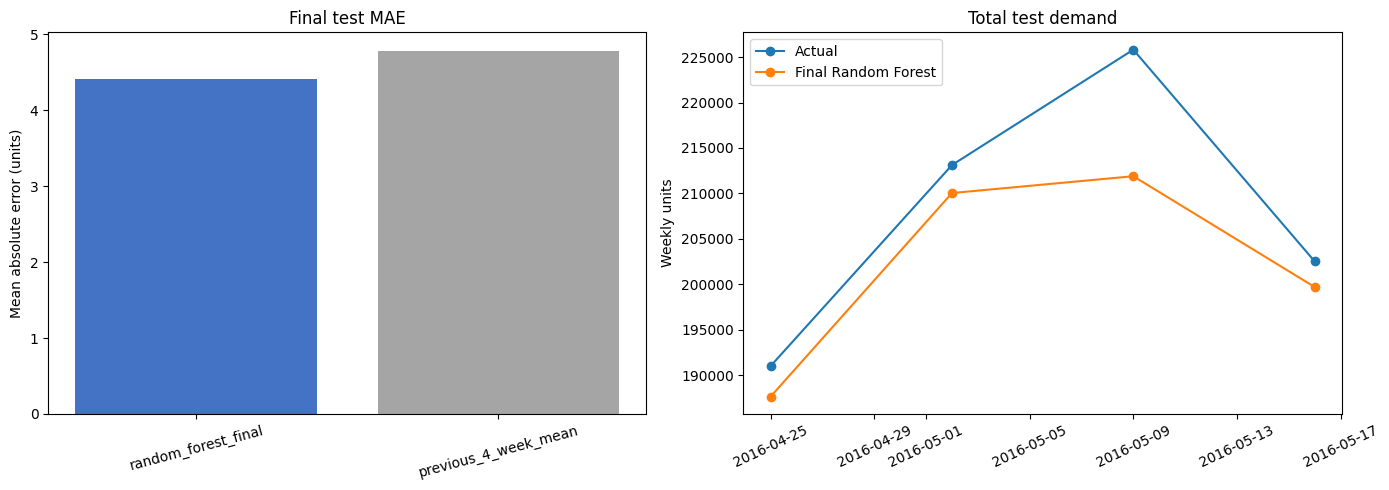

In [7]:
weekly = test_results.groupby("week_start", as_index=False, observed=True).agg(actual_units=(target, "sum"), predicted_units=("prediction", "sum"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(test_comparison["method"], test_comparison["mae"], color=["#4472C4", "#A5A5A5"])
axes[0].set_title("Final test MAE")
axes[0].set_ylabel("Mean absolute error (units)")
axes[0].tick_params(axis="x", rotation=15)
axes[1].plot(weekly["week_start"], weekly["actual_units"], marker="o", label="Actual")
axes[1].plot(weekly["week_start"], weekly["predicted_units"], marker="o", label="Final Random Forest")
axes[1].set_title("Total test demand")
axes[1].set_ylabel("Weekly units")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 8. Result

The frozen Random Forest has now completed its single final test evaluation. These metrics are the final generalization evidence and will not be used for another round of model tuning.